# UTS Praktikum Machine Learning
## Training Model untuk Prediksi Failure Flag pada Agro-Environmental Dataset

Notebook ini berisi proses end-to-end:
1. Load dan inspeksi dataset
2. EDA
3. Data cleaning
4. Preprocessing
5. Training beberapa model
6. Hyperparameter tuning
7. Evaluasi performa
8. Simpan model terbaik untuk deployment

## Import library

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.inspection import permutation_importance
import joblib

sns.set(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load Dataset

Dataset dimuat dari folder `dataset`.  

In [2]:
from pathlib import Path

dataset_dir = Path("../dataset")
csv_files = list(dataset_dir.glob("*.csv"))
print(csv_files)

[WindowsPath('../dataset/agro_environmental_dataset.csv')]


## 2. Struktur Data Awal

Pada tahap ini, saya cek jumlah baris-kolom, tipe data, dan ringkasan statistik awal.

In [5]:
df = pd.read_csv(csv_files[0])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 543210 entries, 0 to 543209
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   location_id               543210 non-null  str    
 1   soil_type                 543210 non-null  str    
 2   bulk_density              543210 non-null  float64
 3   organic_matter_pct        543210 non-null  float64
 4   cation_exchange_capacity  543210 non-null  int64  
 5   salinity_ec               543210 non-null  float64
 6   buffering_capacity        543210 non-null  float64
 7   soil_moisture_pct         543210 non-null  float64
 8   moisture_limit_dry        543210 non-null  int64  
 9   moisture_limit_wet        543210 non-null  int64  
 10  moisture_regime           543210 non-null  str    
 11  soil_temp_c               543210 non-null  float64
 12  air_temp_c                543210 non-null  float64
 13  thermal_regime            543210 non-null  str    
 14 

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
location_id,543210,543210,L00000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
soil_type,543210,9,Loamy,108778,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bulk_density,543210.0,NaN,NaN,NaN,1.319365,0.24307,0.7,1.3,1.3,1.5,1.6
organic_matter_pct,543210.0,NaN,NaN,NaN,4.000303,4.278072,1.2,1.8,3.5,3.8,18.0
cation_exchange_capacity,543210.0,NaN,NaN,NaN,17.212248,10.367455,5.0,8.0,15.0,20.0,40.0
salinity_ec,543210.0,NaN,NaN,NaN,0.673847,0.986025,0.2,0.3,0.4,0.5,4.0
buffering_capacity,543210.0,NaN,NaN,NaN,0.61026,0.198579,0.3,0.4,0.7,0.7,0.9
soil_moisture_pct,543210.0,NaN,NaN,NaN,34.977238,11.927853,5.0,26.87,34.97,43.07,70.0
moisture_limit_dry,543210.0,NaN,NaN,NaN,16.945798,6.61523,8.0,12.0,16.0,22.0,30.0
moisture_limit_wet,543210.0,NaN,NaN,NaN,42.566326,9.681918,28.0,38.0,42.0,45.0,65.0


## 3. Data Cleaning

Langkah ini dilakukan untuk:
- menghapus duplikasi
- mengecek missing value
- membuang kolom identifier yang tidak informatif
- menghindari data leakage dari fitur yang terlalu dekat dengan target

In [7]:
print("Duplikat sebelum:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplikat sesudah:", df.duplicated().sum())

Duplikat sebelum: 0
Duplikat sesudah: 0


In [ ]:
# Cek missing value
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Kolom': missing.index,
    'Jumlah_Null': missing.values,
    'Persentase_%': missing_pct.values
})
missing_df = missing_df[missing_df['Jumlah_Null'] > 0]
print(missing_df)
print(f"\nTotal kolom dengan missing value: {len(missing_df)}")

Empty DataFrame
Columns: [Kolom, Jumlah_Null, Persentase_%]
Index: []

Total kolom dengan missing value: 0


## 4. Identifikasi Target Variable

Target utama yang diprediksi adalah `failure_flag`.

Kolom seperti `location_id` bersifat identifier dan tidak digunakan sebagai fitur.
Kolom `suitability_score` dan `stress_level` saya anggap sebagai kandidat leakage karena sangat dekat dengan target, sehingga tidak dipakai pada model utama.

In [13]:
target_col = "failure_flag"

drop_cols = [c for c in ["location_id", "suitability_score", "stress_level"] if c in df.columns]
print("Kolom yang di-drop:", drop_cols)

df_model = df.drop(columns=drop_cols)

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print(y.value_counts())

Kolom yang di-drop: ['location_id', 'suitability_score', 'stress_level']
Shape X: (543210, 21)
Shape y: (543210,)
failure_flag
0    455130
1     88080
Name: count, dtype: int64


## 5. Analisis Imbalance Target

Distribusi kelas target perlu dicek karena dataset klasifikasi sering tidak seimbang.  
Jika imbalance cukup besar, maka metrik seperti F1-score dan ROC-AUC lebih penting daripada accuracy.

failure_flag
0    455130
1     88080
Name: count, dtype: int64


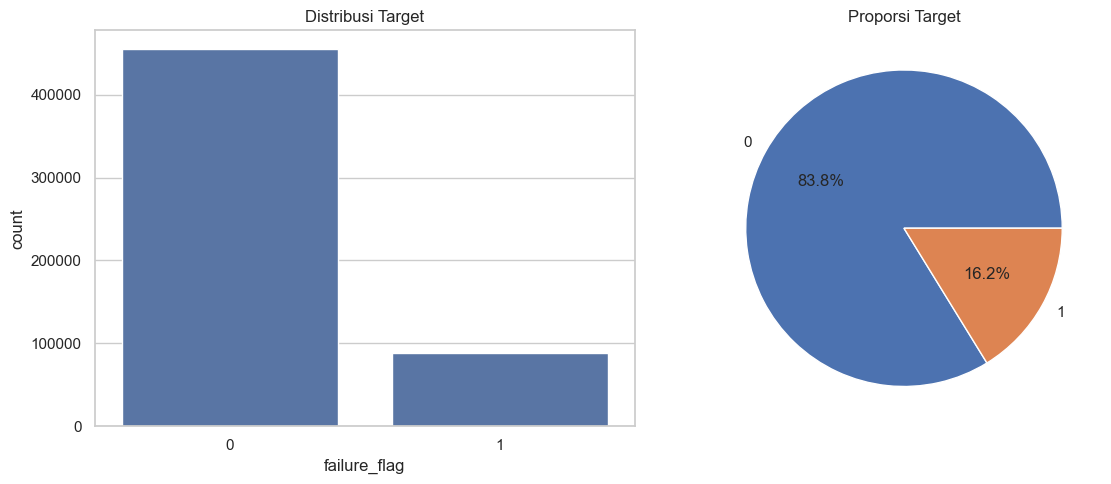

Imbalance ratio (max/min): 5.17


In [14]:
target_dist = y.value_counts()
print(target_dist)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=y)
plt.title("Distribusi Target")

plt.subplot(1, 2, 2)
target_dist.plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Proporsi Target")

plt.tight_layout()
plt.show()

ratio = target_dist.max() / target_dist.min()
print(f"Imbalance ratio (max/min): {ratio:.2f}")

## 6. Exploratory Data Analysis (EDA)

Saya analisis distribusi fitur numerik, outlier, dan korelasi antar fitur untuk memahami pola data.

In [15]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerik:", numeric_cols)
print("Kategorikal:", categorical_cols)

Numerik: ['bulk_density', 'organic_matter_pct', 'cation_exchange_capacity', 'salinity_ec', 'buffering_capacity', 'soil_moisture_pct', 'moisture_limit_dry', 'moisture_limit_wet', 'soil_temp_c', 'air_temp_c', 'light_intensity_par', 'soil_ph', 'ph_stress_flag', 'nitrogen_ppm', 'phosphorus_ppm', 'potassium_ppm']
Kategorikal: ['soil_type', 'moisture_regime', 'thermal_regime', 'nutrient_balance', 'plant_category']


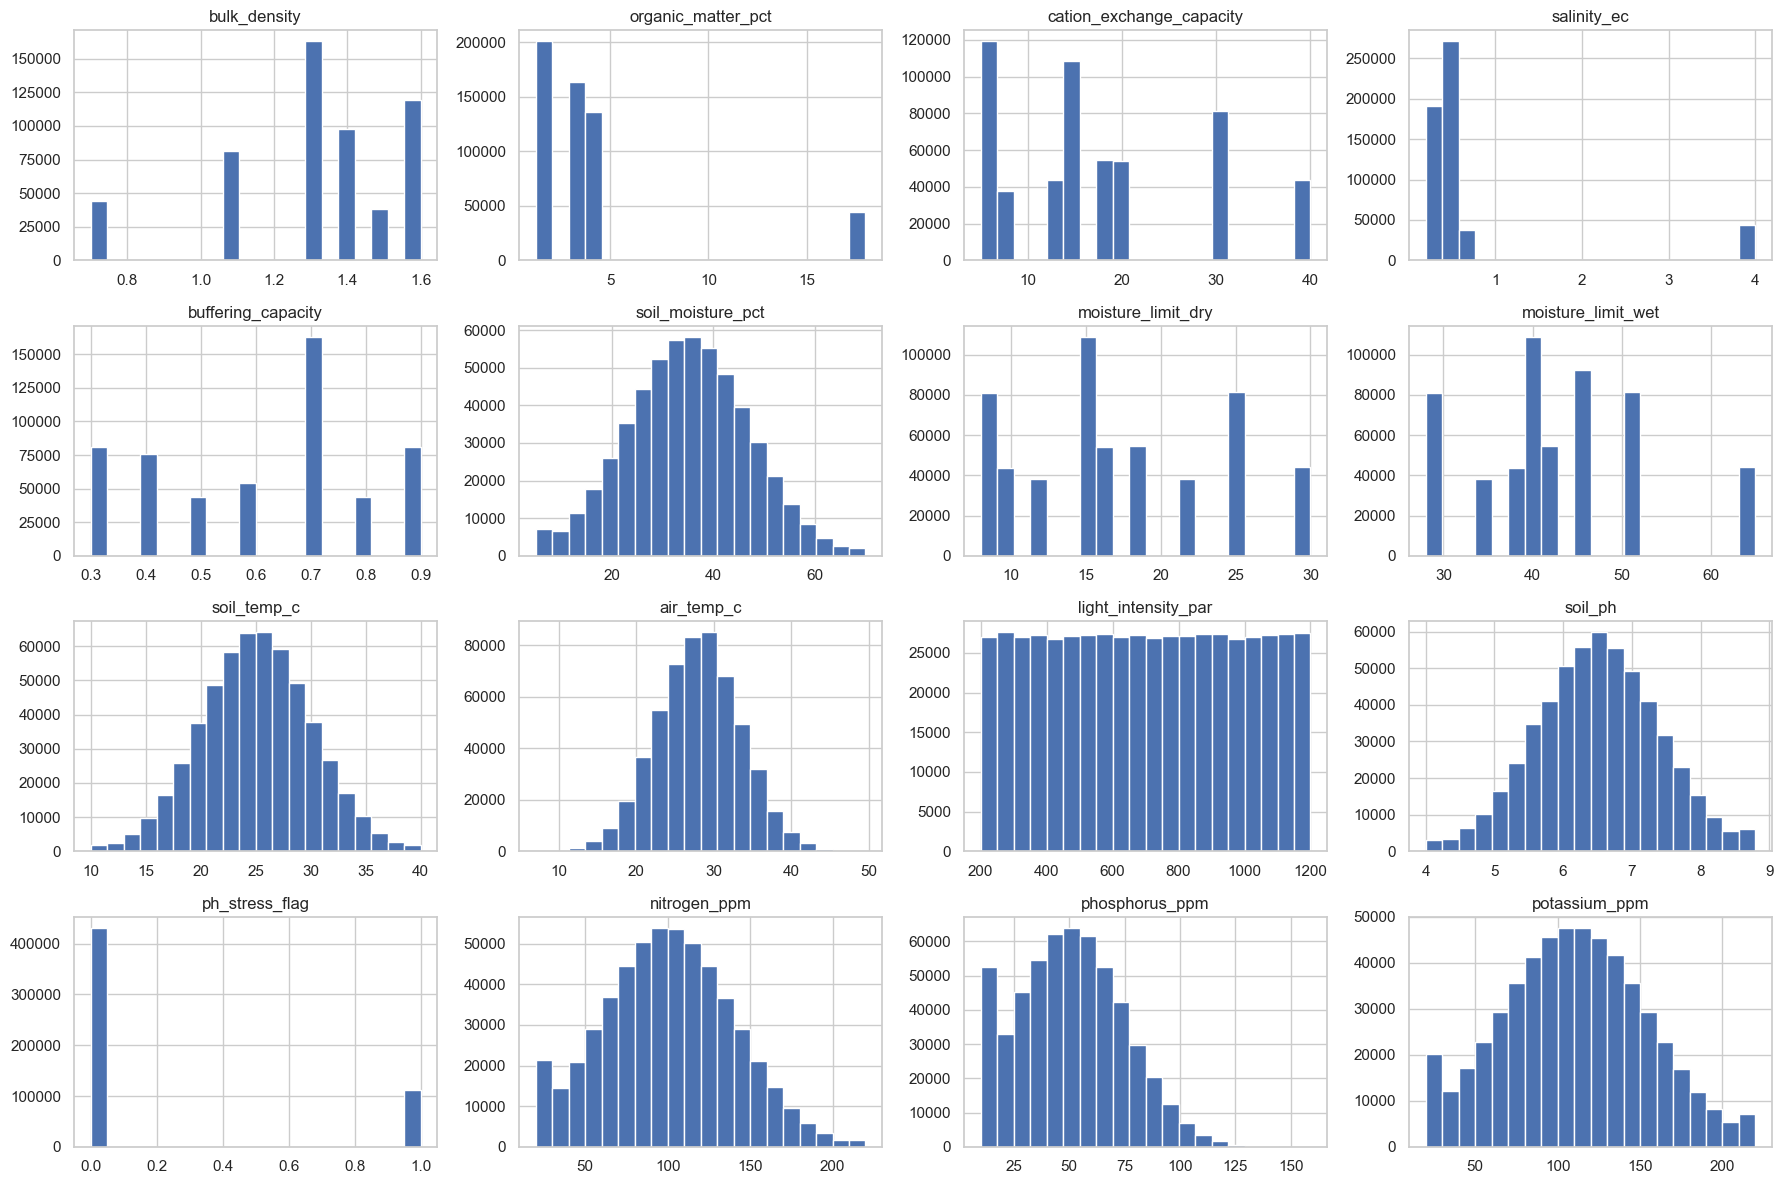

In [16]:
X[numeric_cols].hist(figsize=(18, 12), bins=20)
plt.tight_layout()
plt.show()

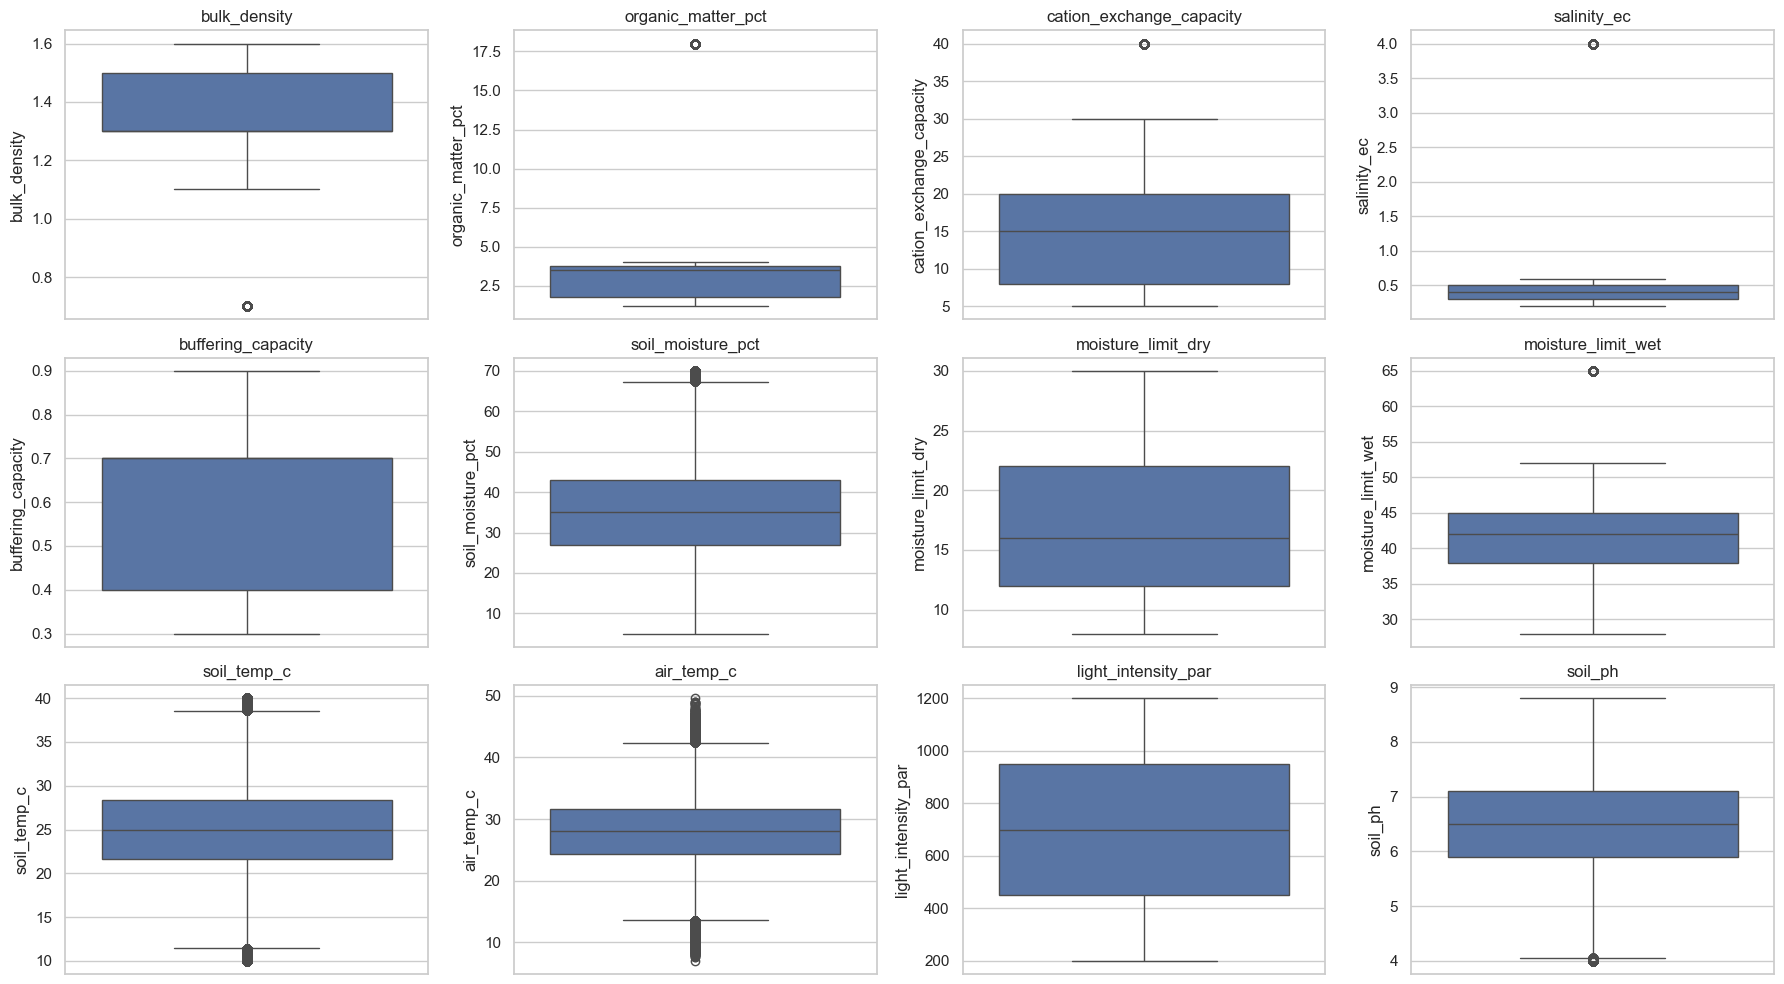

In [17]:
plt.figure(figsize=(18, 10))
for i, col in enumerate(numeric_cols[:12]):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(y=X[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## 7. Korelasi Antar Fitur

Heatmap korelasi digunakan untuk melihat hubungan antar fitur numerik dan mendeteksi fitur yang sangat berkorelasi.

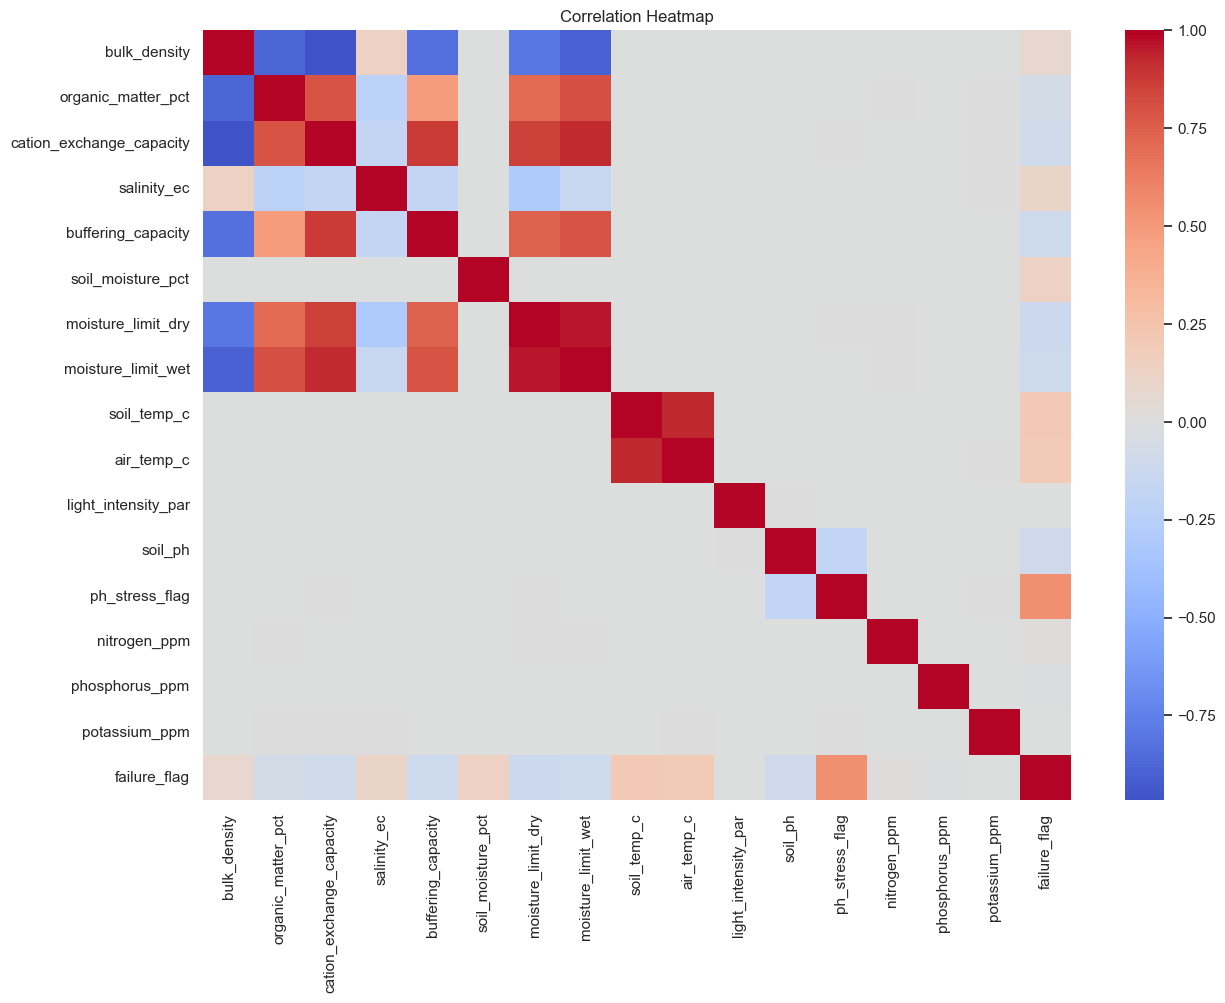

In [18]:
plt.figure(figsize=(14, 10))
corr = df_model[numeric_cols + [target_col]].corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [19]:
corr_target = corr[target_col].sort_values(ascending=False)
corr_target

failure_flag                1.000000
ph_stress_flag              0.552076
soil_temp_c                 0.216402
air_temp_c                  0.201002
soil_moisture_pct           0.137044
salinity_ec                 0.116752
bulk_density                0.084758
nitrogen_ppm                0.009500
potassium_ppm               0.001123
light_intensity_par         0.000776
phosphorus_ppm             -0.009802
organic_matter_pct         -0.069632
cation_exchange_capacity   -0.097666
soil_ph                    -0.099133
buffering_capacity         -0.108961
moisture_limit_wet         -0.111998
moisture_limit_dry         -0.127956
Name: failure_flag, dtype: float64

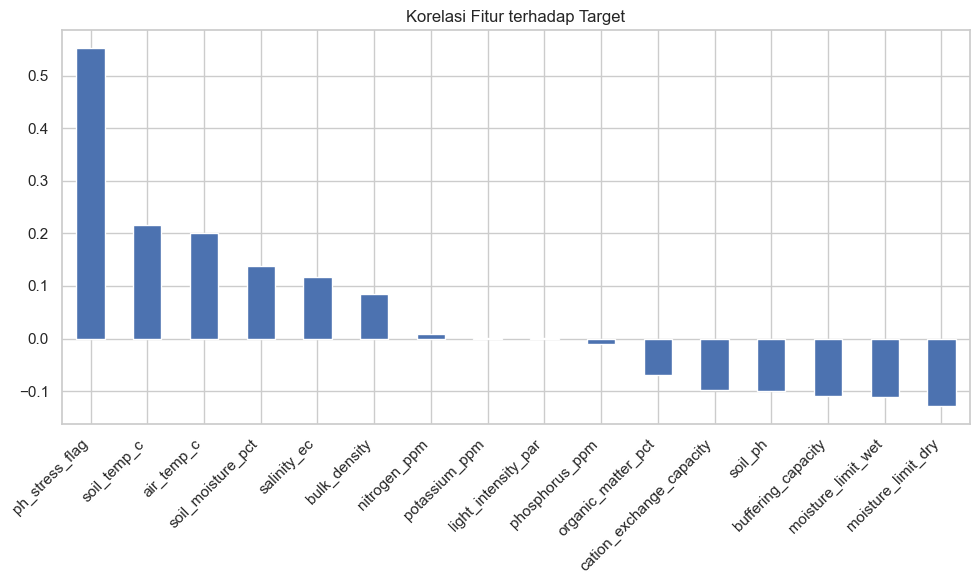

In [20]:
plt.figure(figsize=(10, 6))
corr_target.drop(target_col).plot(kind="bar")
plt.title("Korelasi Fitur terhadap Target")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. Analisis Fitur Kategorikal

Fitur kategorikal perlu dilihat distribusinya karena akan di-encode sebelum training.

In [21]:
for col in categorical_cols:
    print(f"\n{col}")
    print(X[col].value_counts())


soil_type
soil_type
Loamy       108778
Clayey       81261
Sandy        81111
Silty        54407
Alluvial     54183
Peaty        43950
Saline       43465
Laterite     38098
Chalky       37957
Name: count, dtype: int64

moisture_regime
moisture_regime
optimal        319135
waterlogged    171461
dry             52614
Name: count, dtype: int64

thermal_regime
thermal_regime
optimal        413078
heat_stress     86447
cold            43685
Name: count, dtype: int64

nutrient_balance
nutrient_balance
deficient    405882
optimal       91598
excessive     45730
Name: count, dtype: int64

plant_category
plant_category
cereal       217332
vegetable    163163
legume       162715
Name: count, dtype: int64


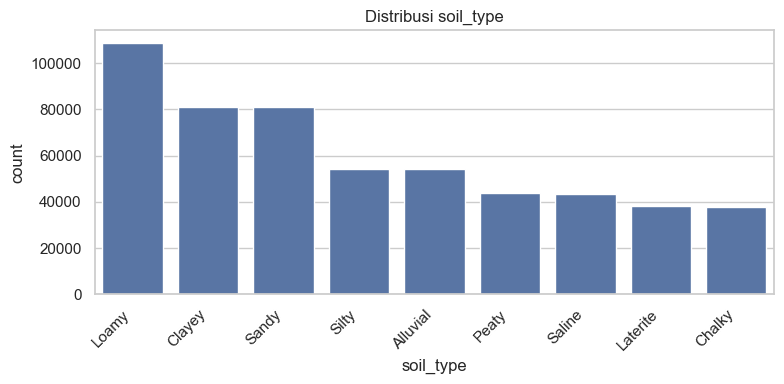

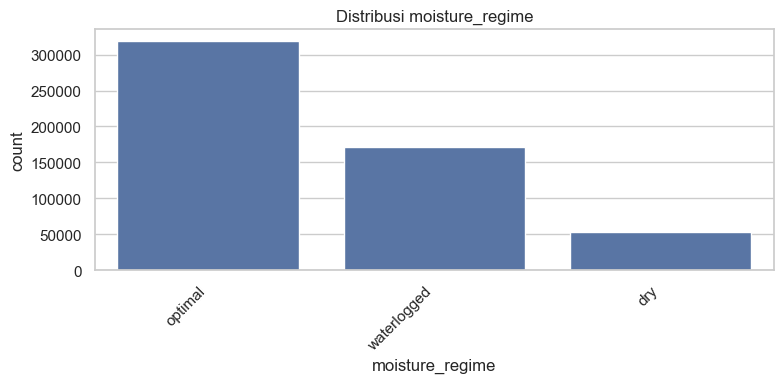

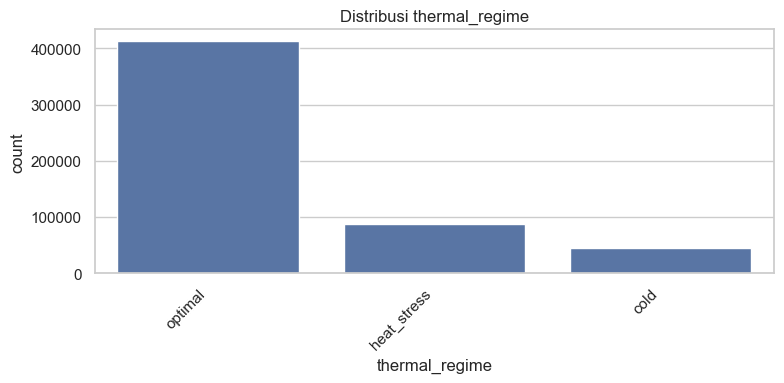

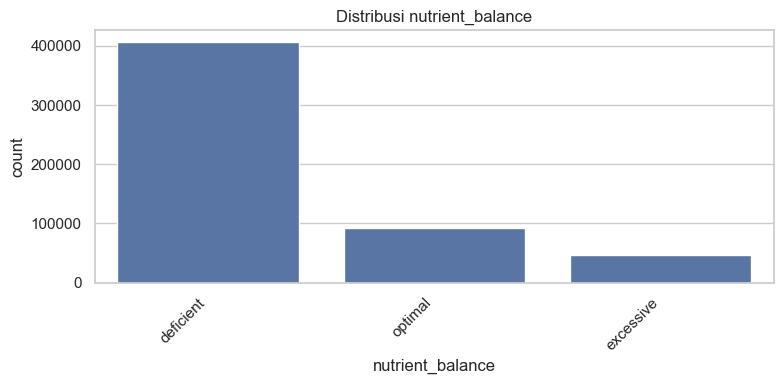

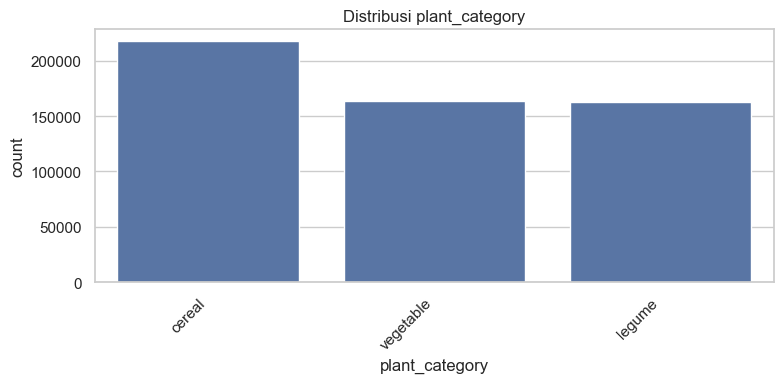

In [22]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=X, x=col, order=X[col].value_counts().index)
    plt.title(f"Distribusi {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 9. Train-Test Split

Data dibagi menjadi data latih dan data uji dengan stratifikasi agar proporsi kelas target tetap terjaga.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (434568, 21) (434568,)
Test : (108642, 21) (108642,)


## 10. Preprocessing

Preprocessing dilakukan dengan pipeline agar:
- imputasi konsisten
- encoding kategorikal konsisten
- scaling numerik konsisten
- aman dari data leakage

In [24]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 11. Training Beberapa Model

Saya gunakan beberapa model untuk pembanding:
- Logistic Regression sebagai baseline
- Random Forest sebagai ensemble bagging
- Voting Classifier sebagai ensemble gabungan

In [25]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    )
}

In [26]:
xgb_available = False
try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    )
    xgb_available = True
    print("XGBoost tersedia.")
except Exception as e:
    print("XGBoost tidak tersedia, dilewati.")
    print(e)

XGBoost tersedia.


## 12. Fungsi Evaluasi

Model dievaluasi menggunakan:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

Untuk data tidak seimbang, F1-Score dan ROC-AUC lebih penting.

In [27]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None
    
    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    }
    return results

## 13. Training Model

Setiap model dibungkus dengan preprocessing pipeline agar transformasi data selalu konsisten.

In [28]:
trained_models = {}
results = []

for name, clf in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", clf)
    ])
    
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe
    
    res = evaluate_model(name, pipe, X_test, y_test)
    results.append(res)
    print(f"{name} selesai dilatih.")

Logistic Regression selesai dilatih.
Random Forest selesai dilatih.
XGBoost selesai dilatih.


## 14. Ensemble Learning: Voting Classifier

Voting Classifier menggabungkan prediksi beberapa model untuk meningkatkan stabilitas dan performa.

In [29]:
estimators = [
    ("lr", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)),
    ("rf", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1))
]

if xgb_available:
    estimators.append((
        "xgb",
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_STATE,
            eval_metric="logloss"
        )
    ))

voting = VotingClassifier(
    estimators=estimators,
    voting="soft"
)

voting_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", voting)
])

voting_pipe.fit(X_train, y_train)
trained_models["Voting Classifier"] = voting_pipe
results.append(evaluate_model("Voting Classifier", voting_pipe, X_test, y_test))

## 15. Hyperparameter Tuning

Saya gunakan GridSearchCV untuk mencari parameter terbaik pada model utama.

In [30]:
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_cv = GridSearchCV(
    rf_pipe,
    param_grid=rf_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

rf_cv.fit(X_train, y_train)
print("Best RF params:", rf_cv.best_params_)
print("Best RF CV score:", rf_cv.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best RF params: {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best RF CV score: 0.9580536743719754


In [31]:
if xgb_available:
    xgb_pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="logloss"
        ))
    ])

    xgb_param_grid = {
        "model__n_estimators": [200, 300],
        "model__max_depth": [4, 6],
        "model__learning_rate": [0.05, 0.1],
        "model__subsample": [0.8, 0.9],
        "model__colsample_bytree": [0.8, 0.9]
    }

    xgb_cv = GridSearchCV(
        xgb_pipe,
        param_grid=xgb_param_grid,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="f1",
        n_jobs=-1,
        verbose=1
    )

    xgb_cv.fit(X_train, y_train)
    print("Best XGB params:", xgb_cv.best_params_)
    print("Best XGB CV score:", xgb_cv.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best XGB params: {'model__colsample_bytree': 0.9, 'model__learning_rate': 0.05, 'model__max_depth': 6, 'model__n_estimators': 300, 'model__subsample': 0.8}
Best XGB CV score: 0.9578703893469094


## 16. Evaluasi Model Terbaik

Model terbaik dipilih berdasarkan F1-Score dan ROC-AUC pada data test.

In [32]:
# tambahkan hasil tuning ke daftar hasil
results.append(evaluate_model("Random Forest Tuned", rf_cv.best_estimator_, X_test, y_test))
trained_models["Random Forest Tuned"] = rf_cv.best_estimator_

if xgb_available:
    results.append(evaluate_model("XGBoost Tuned", xgb_cv.best_estimator_, X_test, y_test))
    trained_models["XGBoost Tuned"] = xgb_cv.best_estimator_

results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
4,Random Forest Tuned,0.987068,0.969421,0.950216,0.959723,0.997691
5,XGBoost Tuned,0.987086,0.980158,0.939373,0.959332,0.997687
3,Voting Classifier,0.986865,0.964907,0.953678,0.959260,0.997364
2,XGBoost,0.987040,0.979697,0.939544,0.959200,0.997733
1,Random Forest,0.986828,0.983048,0.934889,0.958364,0.997716
0,Logistic Regression,0.971760,0.877909,0.959242,0.916775,0.992052


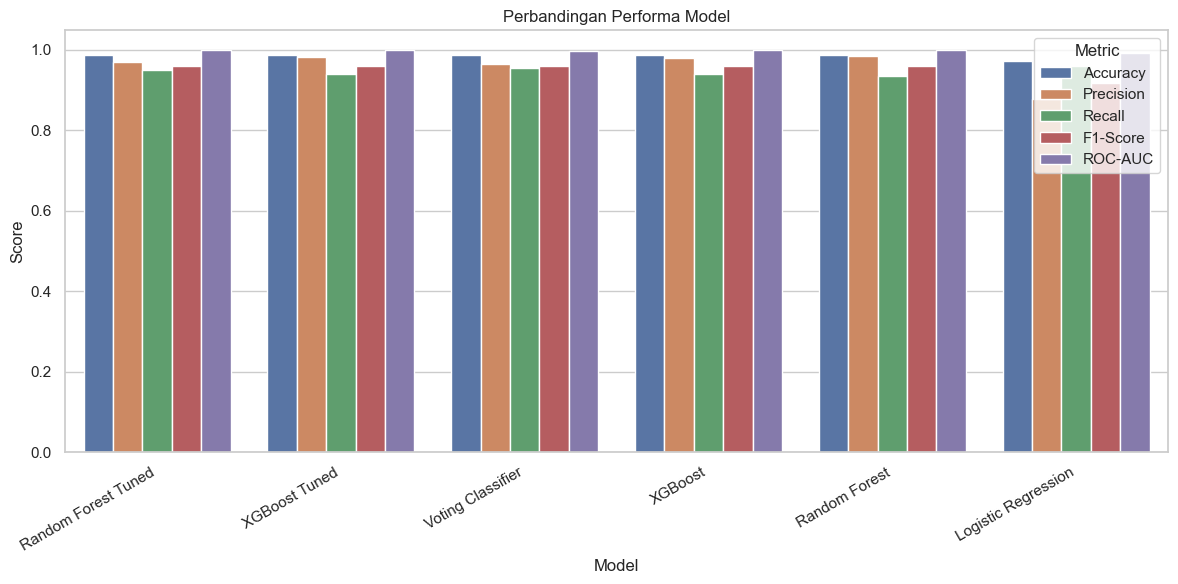

In [33]:
plt.figure(figsize=(12, 6))
results_melt = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=results_melt, x="Model", y="Score", hue="Metric")
plt.xticks(rotation=30, ha="right")
plt.title("Perbandingan Performa Model")
plt.tight_layout()
plt.show()

## 17. Confusion Matrix dan Classification Report

Bagian ini menunjukkan detail kesalahan klasifikasi pada model terbaik.

In [34]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else None

print("Best model:", best_model_name)
print(classification_report(y_test, y_pred, zero_division=0))

Best model: Random Forest Tuned
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     91026
           1       0.97      0.95      0.96     17616

    accuracy                           0.99    108642
   macro avg       0.98      0.97      0.98    108642
weighted avg       0.99      0.99      0.99    108642



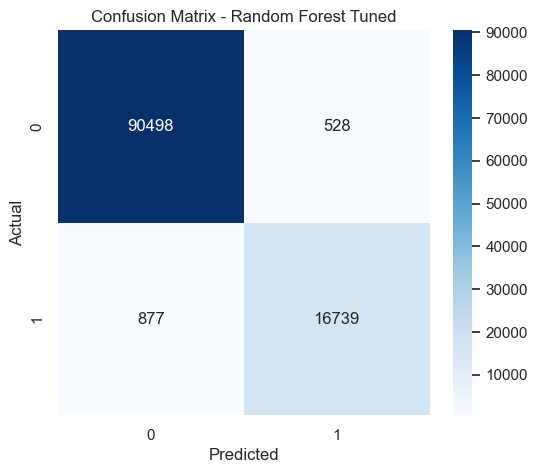

In [35]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

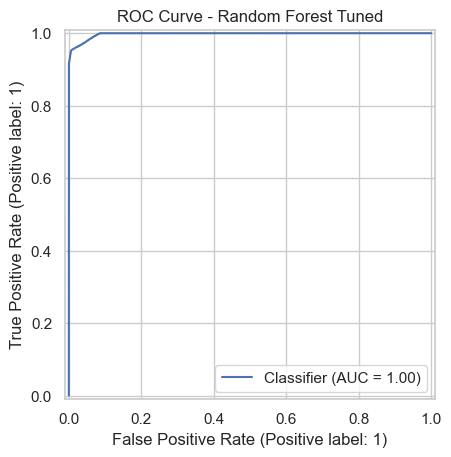

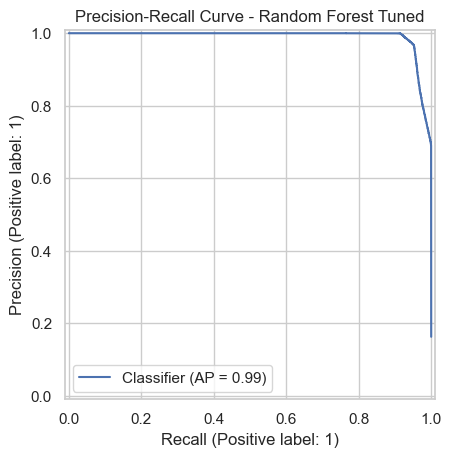

In [36]:
if y_proba is not None:
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title(f"ROC Curve - {best_model_name}")
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test, y_proba)
    plt.title(f"Precision-Recall Curve - {best_model_name}")
    plt.show()

## 18. Analisis Feature Importance

Untuk model tree-based, feature importance membantu melihat fitur mana yang paling berpengaruh.

In [37]:
# ambil model tree-based terbaik jika ada
tree_model = None
for candidate in ["Random Forest Tuned", "XGBoost Tuned", "Random Forest", "XGBoost"]:
    if candidate in trained_models:
        tree_model = trained_models[candidate]
        break

tree_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

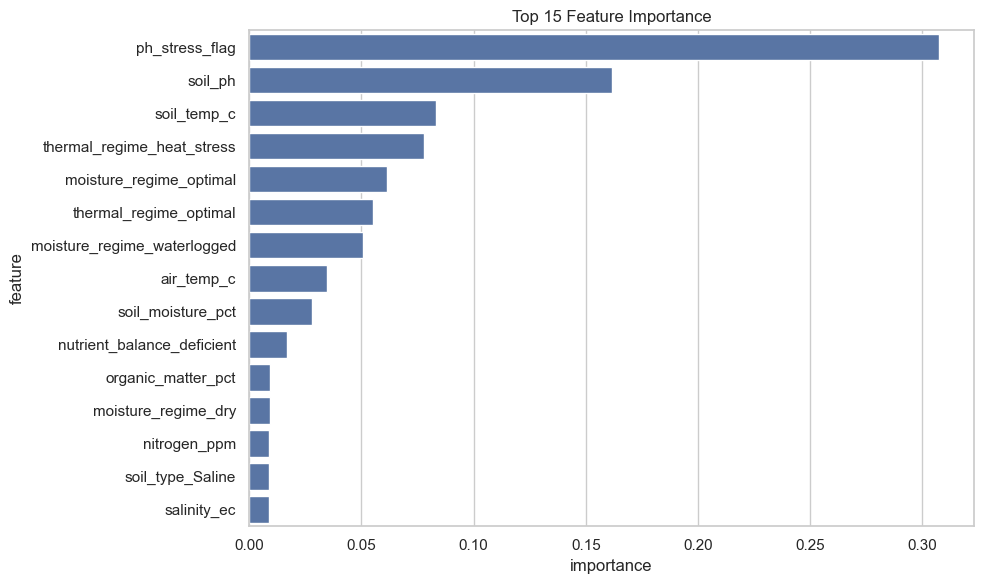

In [38]:
if tree_model is not None:
    fitted_preprocessor = tree_model.named_steps["preprocessor"]
    model = tree_model.named_steps["model"]

    feature_names = []
    if len(categorical_features) > 0:
        ohe = fitted_preprocessor.named_transformers_["cat"].named_steps["onehot"]
        cat_names = list(ohe.get_feature_names_out(categorical_features))
    else:
        cat_names = []

    feature_names = numeric_features + cat_names

    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        feat_imp = pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        }).sort_values(by="importance", ascending=False)

        plt.figure(figsize=(10, 6))
        sns.barplot(data=feat_imp.head(15), x="importance", y="feature")
        plt.title("Top 15 Feature Importance")
        plt.tight_layout()
        plt.show()

        feat_imp.head(20)

## 19. Simpan Model

Model terbaik disimpan dalam bentuk pipeline utuh agar preprocessing dan prediksi tetap konsisten saat deployment.

In [39]:
OUTPUT_DIR = Path("../model")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

model_path = OUTPUT_DIR / f"{best_model_name.replace(' ', '_').lower()}_pipeline.pkl"
joblib.dump(best_model, model_path)

print("Model saved to:", model_path)

Model saved to: ..\model\random_forest_tuned_pipeline.pkl


## 20. Contoh Inferensi

Bagian ini berguna untuk memastikan model siap menerima input baru.

In [40]:
sample_input = X_test.iloc[:1].copy()
sample_input

,soil_type,bulk_density,organic_matter_pct,cation_exchange_capacity,salinity_ec,buffering_capacity,soil_moisture_pct,moisture_limit_dry,moisture_limit_wet,moisture_regime,...,air_temp_c,thermal_regime,light_intensity_par,soil_ph,ph_stress_flag,nitrogen_ppm,phosphorus_ppm,potassium_ppm,nutrient_balance,plant_category
115126,Sandy,1.6,1.2,5,0.4,0.3,35.39,8,28,waterlogged,...,32.3,optimal,1003.0,6.15,0,86.5,65.4,92.1,deficient,vegetable


In [41]:
pred_class = best_model.predict(sample_input)[0]
pred_prob = best_model.predict_proba(sample_input)[0, 1] if hasattr(best_model, "predict_proba") else None

print("Prediksi kelas:", pred_class)
if pred_prob is not None:
    print("Probabilitas kelas 1:", pred_prob)

Prediksi kelas: 0
Probabilitas kelas 1: 0.0012157711263373003


## 21. Kesimpulan

Dari proses training ini:
- dataset telah dianalisis melalui EDA
- fitur identifier dan fitur yang berpotensi leakage telah dikeluarkan
- preprocessing dilakukan dengan pipeline
- beberapa model dibandingkan secara objektif
- tuning dilakukan untuk model terbaik
- model akhir disimpan dalam format pipeline untuk deployment